In [1]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l  

In [2]:
#import d2l
#d2l.torch??

In [3]:
#import torch
#torch??

In [4]:
#import inspect 
#print(inspect.getsourcefile(torch))

In [5]:
dir(d2l.torch)

['AVG',
 'AcceleratorError',
 'AggregationType',
 'AliasDb',
 'AnyType',
 'Argument',
 'ArgumentSpec',
 'AwaitType',
 'BFloat16Storage',
 'BFloat16Tensor',
 'BenchmarkConfig',
 'BenchmarkExecutionStats',
 'Block',
 'BoolStorage',
 'BoolTensor',
 'BoolType',
 'BufferDict',
 'ByteStorage',
 'ByteTensor',
 'CallStack',
 'Capsule',
 'CharStorage',
 'CharTensor',
 'ClassType',
 'Code',
 'CompilationUnit',
 'CompleteArgumentSpec',
 'ComplexDoubleStorage',
 'ComplexFloatStorage',
 'ComplexType',
 'ConcreteModuleType',
 'ConcreteModuleTypeBuilder',
 'DeepCopyMemoTable',
 'DeserializationStorageContext',
 'DeviceObjType',
 'DictType',
 'DisableTorchFunction',
 'DisableTorchFunctionSubclass',
 'DispatchKey',
 'DispatchKeySet',
 'DoubleStorage',
 'DoubleTensor',
 'EnumType',
 'ErrorReport',
 'Event',
 'ExcludeDispatchKeyGuard',
 'ExecutionPlan',
 'FatalError',
 'FileCheck',
 'FloatStorage',
 'FloatTensor',
 'FloatType',
 'FunctionSchema',
 'Future',
 'FutureType',
 'Generator',
 'GradScaler',
 'G

In [6]:
def synthetic_data(w,b,num_example):
    "y = Xw + b + 噪声"
    X = torch.normal(0,1,(num_example,len(w)))  #均值为0 标准差为1的正态分布 num_example表示你输入有多少个样本 len(w)样本特征的长度是什么
    y = torch.matmul(X,w)+b #把根据输入生成的样本个数，正态分布，生成一个有num_example个数的，len(w)个数的矩阵 的特征值矩阵  这时候的y = 矩阵 * 向量得到的向量，然后加上b 这里我们后面会给b赋值
    y += torch.normal(0,1,y.shape) #然后用方差为0 标准差为1的正态分布，生成一个和y一样的形状的 y现在的形状就是一个向量 然后生成一个同样形状的向量噪音 加上自己 这样就会得到一个新的y 根据公式我们知道这个就是结果
    return X,y.reshape(-1,1)  #这里就是我们的返回值 我们要返回一个X有多少个w的特征矩阵， 以及结果以及结果y ,由于现在我们还不知道我们输入的num_example的输入值是什么所以我们用-1表示全部输出， 1表示1列 就是我们求出来的形状

true_w = torch.tensor([2,-3.4])
true_b = 4.2
features,labels = synthetic_data(true_w,true_b,1000)  #这里我们再强调一下我们的返回值， 一个特征矩阵[1000,2]  一个向量的答案[1000,1]

In [7]:
print(features)

tensor([[-0.0911,  0.4992],
        [ 1.4070, -2.0673],
        [ 2.9925,  0.2295],
        ...,
        [-0.5300, -0.8208],
        [-0.5537,  0.6804],
        [ 1.1370, -1.0441]])


In [8]:
print(features.shape)

torch.Size([1000, 2])


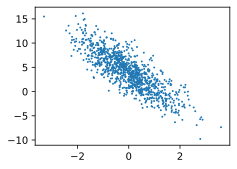

In [9]:
d2l.set_figsize()
d2l.plt.scatter(features[:,1].detach(), labels.detach().numpy(),1 ); #这里的1是指第1列的分布吗 后面的labels .detach()是一个 什么函数， 这个detach的单词是什么意思， numpy() 这里是什么意思， 什么事numpy()


(-3000.0, 3000.0)

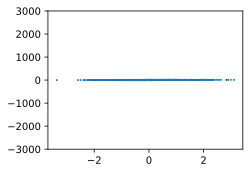

In [10]:
d2l.plt.scatter(features[:,0].detach(), labels.detach().numpy(), 1)
d2l.plt.ylim(-3000, 3000)   # 强制把y轴范围锁定成这个区间

(-3000.0, 3000.0)

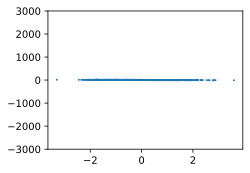

In [11]:
d2l.plt.scatter(features[:,1].detach(), labels.detach().numpy(), 1)
d2l.plt.ylim(-3000, 3000)   # 强制把y轴范围锁定成这个区间

In [12]:
print(features)

tensor([[-0.0911,  0.4992],
        [ 1.4070, -2.0673],
        [ 2.9925,  0.2295],
        ...,
        [-0.5300, -0.8208],
        [-0.5537,  0.6804],
        [ 1.1370, -1.0441]])


In [13]:
print(labels[:5])

tensor([[ 2.3581],
        [15.5921],
        [10.5957],
        [-3.7725],
        [ 6.7131]])


In [14]:
"..." in str(labels)

False

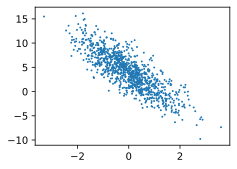

In [15]:
d2l.set_figsize()
d2l.plt.scatter(features[:,1],labels,1);

In [16]:
def data_iter(batch_size,features,labels):  #定义一个迭代器 迭代的批次号，输入特征和结果用于 ，批量训练
    num_example =(len(features)) #获取特征的长度  有多少个特征 这里是行有1000个特征，为什么len就是取的行
    print(num_example)  #打印一下我输入的行的个数
    indices = list(range(num_example)) #这里的目的是生成下标索引，长度和features一样的长 features是张量， range要整数
    random.shuffle(indices) #我们打乱这个下标
    for i in range(0,num_example,batch_size): #这里我们用了for循环，然后生成一个起点为0 终点为num_example , 取大小为beatch_size=10
        batch_indices = torch.tensor(
            indices[i:min(i+batch_size,num_example)])
        print("打印打乱的当前批次号：",indices[:10])
        print("打印打乱的当前批次号里面的值：",batch_indices)
        yield features [batch_indices],labels[batch_indices]
            
batch_size = 10
for x,y in data_iter(batch_size,features,labels):
    print(x,'\n' ,y)
    break 
                   
                   
        

1000
打印打乱的当前批次号： [99, 819, 678, 476, 934, 694, 835, 799, 229, 317]
打印打乱的当前批次号里面的值： tensor([ 99, 819, 678, 476, 934, 694, 835, 799, 229, 317])
tensor([[-0.5090, -0.7028],
        [ 1.4602,  0.1905],
        [-0.9334, -0.5610],
        [ 0.3768,  0.0561],
        [-1.3911, -0.0147],
        [ 0.1051,  0.3356],
        [-0.5897,  0.5280],
        [-0.4148, -0.3198],
        [-0.7303, -1.9479],
        [ 0.7463, -1.6981]]) 
 tensor([[ 6.2057],
        [ 6.0786],
        [ 3.8181],
        [ 4.3435],
        [ 2.1302],
        [ 2.4354],
        [-0.0849],
        [ 1.9529],
        [ 8.8195],
        [12.5617]])


In [17]:
w = torch.normal(0,0.01,size=(2,1),requires_grad=True) #正态分布，均值为0 标准差为1 形状为(2,1) 请求记录梯度
print("w:",w)
b = torch.zeros(1,requires_grad=True) #requires =需要，request=请求动词原形
print('b:',b)
c =torch.tensor([1.0])
c =torch.ones(1,requires_grad=True)
print(c)


w: tensor([[-0.0059],
        [ 0.0122]], requires_grad=True)
b: tensor([0.], requires_grad=True)
tensor([1.], requires_grad=True)


In [18]:
def linreg(X,w,b): # liner regression
    """ 线性回归模型 """
  
    return torch.matmul (X,w) + b  #我定义了一个线性回归的模型， 矩阵乘向量，然后加b


In [19]:
pred =linreg(features ,w ,b) # features是我们生成的特征，w是我们初始化的起始点，b也是我们初始话的值，，我们从这个位置开始对把初始化的值带入求开始轮的第一个值求出了每一个样本的预测值
print(pred[:10])
#这里是不是就已经进行了正向传播运算了把每一个正向的值存起来了 forward propagation 前向和后向说的是计算方向 梯度只有在反向传播时才会产生 这里的grad_fn=<SlinceBackward0> 这里pytorch确实在前向传播时偷偷记账了
#前向传播跑完后， w.grad依然是None 只有backward()之后才能变成【0.412。而grad_fn在每一步都变：matmul 之后， MmBackward0 Matrix multiply加b之后 它在记录每一步用了什么运算 为将来的反向传播做准备

tensor([[ 0.0066],
        [-0.0335],
        [-0.0148],
        [ 0.0200],
        [-0.0062],
        [ 0.0182],
        [ 0.0091],
        [ 0.0163],
        [-0.0042],
        [ 0.0171]], grad_fn=<SliceBackward0>)


In [20]:
def squared_loss(y_hat,y):
    """loss( y_hat - y)**2/2"""
    return  ((y_hat)-y.reshape(y_hat.shape))**2/2  #这里就是求loss 上面就是求预测值，我们要将 损失 = 预测值-实际值  然后求loss就是将 损失平方除2 这里的返回值就是loss

In [21]:
loss_1 = squared_loss(pred,labels)
print(loss_1[:10])
pred.shape
labels.shape #这里由于两个值一样所以就打印了一个吗。jupyter子送现实最后一行表达式的结果 想要两个都看到就要使用print 

tensor([[2.7648e+00],
        [1.2208e+02],
        [5.6291e+01],
        [7.1915e+00],
        [2.2574e+01],
        [3.7385e-01],
        [2.9336e-01],
        [5.0887e-02],
        [8.9772e+00],
        [7.0926e-01]], grad_fn=<SliceBackward0>)


torch.Size([1000, 1])

In [28]:
def sgd (params,lr,batch_size):
    with torch.no_grad():
        """小批量随机梯度下降"""
        for param in params:  #这里用的是for 循环不是form , 把 param 从params里拿出来
            param -= lr * param.grad/batch_size  #这里的param  = 学习率乘w param.grad 求导之后就是梯度的概念里  学习率 * 梯度 /批次号就是10个数的平均梯度  然后把取出来的值清零
            #我们用老的梯度  这里是 param = param - =后面的所有 ，所以老的梯度- 新的学习率乘上新的param求导后就是新的梯度， 这里的param 是误差 * x1求导 这里的param就是批次里取出来的10个数一起求导然后一起乘学习率，然后除10 
            #但是我们这个paras从哪里来的这里没有说清楚，这个函数就是把老的误差拿来 用新的梯度老的梯度减去新的梯度
            param.grad.zero_()   #这里是把值清零不是把梯度清零 param是我们得到的新的梯度 
        

In [31]:
lr = 0.003
num_epochs = 10
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X,y in data_iter(batch_size,features,labels):
        l=loss(net(X,w,b),y)
        l.sum().backward()
        sgd([w,b],lr,batch_size)
        with torch.no_grad():
            train_l = loss(net(features,w,b),labels);
    print(f'epoch{epoch+1},loss{float(train_l.mean()):f}')



1000
打印打乱的当前批次号： [228, 182, 342, 298, 837, 442, 108, 761, 5, 910]
打印打乱的当前批次号里面的值： tensor([228, 182, 342, 298, 837, 442, 108, 761,   5, 910])
打印打乱的当前批次号： [228, 182, 342, 298, 837, 442, 108, 761, 5, 910]
打印打乱的当前批次号里面的值： tensor([189, 107, 110, 815, 993, 568, 370, 210, 451, 638])
打印打乱的当前批次号： [228, 182, 342, 298, 837, 442, 108, 761, 5, 910]
打印打乱的当前批次号里面的值： tensor([ 92, 221, 160, 223, 414, 647, 572, 336, 634, 444])
打印打乱的当前批次号： [228, 182, 342, 298, 837, 442, 108, 761, 5, 910]
打印打乱的当前批次号里面的值： tensor([178,  63, 736,  82, 878, 138, 368, 997, 330, 531])
打印打乱的当前批次号： [228, 182, 342, 298, 837, 442, 108, 761, 5, 910]
打印打乱的当前批次号里面的值： tensor([799,  89, 763, 447, 321, 255, 335, 175, 609, 643])
打印打乱的当前批次号： [228, 182, 342, 298, 837, 442, 108, 761, 5, 910]
打印打乱的当前批次号里面的值： tensor([895, 889, 566, 640, 143, 789, 285, 279, 216,  45])
打印打乱的当前批次号： [228, 182, 342, 298, 837, 442, 108, 761, 5, 910]
打印打乱的当前批次号里面的值： tensor([410, 801, 481, 254, 797, 570, 902, 827,  75, 490])
打印打乱的当前批次号： [228, 182, 342, 298, 837, 442, 

In [ ]:
pred.shape
#labels.shape

In [ ]:
labels.shape

In [ ]:
testshape = list(range(100))
testshape[:10]
testshape

In [ ]:
testshape[:10]  #这里很有意思，它知道自己是一个列表所以没有形状所以很长的话就竖着排列，很短的话横着排列

In [ ]:
#对了我们刚刚还说了如何创建一个张量
first_tensor = torch.tensor(range(10))  #我真牛啊，这个我没有看任何参考我自己写出来的
first_tensor

In [ ]:
print(first_tensor.shape) #只有张量才有形状 可惜是一个1维的张量但是 但是并没有看到你说的“，” 
first_tensor.shape

In [ ]:
second = torch.tensor(range(0,100)) #左开右闭
second.shape  #这里为什么是一个0   我要如何创建一个张量，其实我之前学过那知识学过现在我要自己创建就是输出和只是看一下并不一样这可能就是区别吧
print(tuple(first_tensor.shape))

In [ ]:
A = range(100,100) #空。range 不存数字只存配方， 起点终点步长
B = range(0,100)
#C = range(0,100000000)  #这里用的1亿个数 和range （100，200）100个数占用的内存完全一样
#print(list(C)[:10]) #想看数字用list展开
list(C[:10])
print(tuple(first_tensor))#python里的惰性求值 

In [ ]:
#1维 的张量创建
a = torch.arange(10) 
a = torch.tensor([0,1,2,3,4,5,6,7])
a = torch.zeros(10)  #1维的张量没有横和竖的张量的概念
a

In [ ]:
#2维的张量创建竖置
b = torch.arange(10).reshape(10,1)
b = torch.zeros(10,1)
b

In [ ]:
#2维张量创建横着
b = torch.arange(10).reshape(1,10)
b

In [ ]:
d = torch.arange(10).reshape(-1,1)
d

In [ ]:
d = torch.arange(10).reshape(1,-1)
d

In [ ]:
import torch
a = torch.arange(5)
b = torch.arange(5).reshape(5,1)
c = torch.arange(5).reshape(1,5)
print (" a",tuple(a.shape),a.tolist())
print ("b" ,tuple(b.shape),b.tolist())
print ("c" ,tuple(c.shape),c.tolist())

In [ ]:
# 减法: 看哪些会炸成 5x5
print("b - b :", tuple((b - b).shape), "  正常")
print("b - a :", tuple((b - a).shape), "  <- 炸了")
print("b - c :", tuple((b - c).shape), "  <- 炸了")
print("a - a :", tuple((a - a).shape), "  正常")
print()

In [ ]:
b

In [ ]:
print ("b-b)",((b-b).shape))

In [ ]:
b

In [ ]:
b-b

In [ ]:
b-a

In [ ]:
b-c

In [ ]:
a-b

In [ ]:
c-a

In [ ]:
print (X.shape)
print (w.shape)
print (b.shape)